<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_06_normal_equations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 6 : Ecuación normal

Se puede encontrar una solucion exacta para theta sin necesidad de emplear el gradiente descente de la sesiones pasadas, para ellos se puede encontrar el valor minimo de theta y a partir de alli determinar el valor de theta que minimiza J.

Los pasos para esta minimizacion se dejan como tarea, y pueden ser calculados según lo siguiente:

Si J es la funcion de coste dada por:

\begin{equation}
J(\theta_1,\theta_2,\theta_3, ...,\theta_n )=\frac{1}{2m} \sum_{i = 1}^m (\Theta^{T} X - \hat{y}^{(i)})^2
\end{equation}


Demostrar que:

- $J(\theta_1,\theta_2,\theta_3, ...,\theta_n ) = \frac{1}{2m} (\Theta ^ T X - y^T) (\Theta ^ T X - y^T)^T$

- $J= (\Theta ^T X) (\Theta ^T X)^T - 2(\Theta ^T X)Y  + Y^TY $


- $ \nabla _{\theta} J = \frac{1}{m} (2 X(X^T \Theta) -2XY)$


Para encontrar el valor minimo de \theta,  $\nabla _{\theta} J = 0$,

- $\Theta = (X^T X)^{-1} X^T y$



En este caso,tenemos que:

sea $X \in R^{n\times m}$ ,  $X^T \in R^{m\times n}$

sea $Y \in R^{m \times 1}$,  $Y^T \in R^{1 \times m}$

sea $\Theta \in R^{n \times 1}$, $\Theta^T \in R^{1 \times n}$




Para la demostracion anterior emplee las siguientes propiedades:

- $z^T z= \sum_i z_i^2$
- $a^T b = b^Ta$
- $\nabla _x b^T x = b$
- $\nabla _x  x^T A x = 2Ax$

donde a, b, x son matrices, $\nabla_x$ es la derivada respecto al vector x, y A es una matriz simétrica

---
## Demostración: Derivación de la ecuación normal

> **Convención de dimensiones usada en este laboratorio:**  
> $X \in \mathbb{R}^{n \times m}$ (features × muestras),  
> $\Theta \in \mathbb{R}^{n \times 1}$,  
> $Y \in \mathbb{R}^{m \times 1}$

---

### Paso 1 — Expresar $J$ como producto matricial

Partimos de la función de coste:

$$J = \frac{1}{2m} \sum_{i=1}^{m} \left(\Theta^T X^{(i)} - y^{(i)}\right)^2$$

Definimos el vector fila de errores $\mathbf{e}^T = \Theta^T X - Y^T \in \mathbb{R}^{1 \times m}$. Usando la propiedad $z^T z = \sum_i z_i^2$ con $z = \mathbf{e}$:

$$\sum_{i=1}^{m}\left(\Theta^T X^{(i)} - y^{(i)}\right)^2 = \mathbf{e}\, \mathbf{e}^T = (\Theta^T X - Y^T)(\Theta^T X - Y^T)^T$$

Por lo tanto:

$$\boxed{J = \frac{1}{2m}(\Theta^T X - Y^T)(\Theta^T X - Y^T)^T}$$

---

### Paso 2 — Expansión del producto

Sean $A = \Theta^T X \in \mathbb{R}^{1 \times m}$ y $B = Y^T \in \mathbb{R}^{1 \times m}$. Expandiendo $(A - B)(A - B)^T$:

$$(A - B)(A-B)^T = AA^T - AB^T - BA^T + BB^T$$

Dado que todos los términos son escalares ($1 \times 1$), se cumple $AB^T = BA^T$ (un escalar es igual a su transpuesto). Luego:

$$(A - B)(A-B)^T = (\Theta^T X)(\Theta^T X)^T - 2(\Theta^T X)Y + Y^T Y$$

$$\boxed{J = \frac{1}{2m}\left[(\Theta^T X)(\Theta^T X)^T - 2(\Theta^T X)Y + Y^T Y\right]}$$

---

### Paso 3 — Cálculo del gradiente $\nabla_\Theta J$

Reescribimos cada término en función de $\Theta$, notando que:

$$( \Theta^T X)(\Theta^T X)^T = \Theta^T (XX^T) \Theta$$

Esta es una **forma cuadrática** en $\Theta$ con la matriz simétrica $A = XX^T$. Aplicando $\nabla_x \, x^T A x = 2Ax$:

$$\nabla_\Theta\left[\Theta^T(XX^T)\Theta\right] = 2\,(XX^T)\Theta = 2\,X(X^T\Theta)$$

Para el término lineal, $(\Theta^T X)Y = \Theta^T(XY)$. Aplicando $\nabla_x\, b^T x = b$ con $b = XY$:

$$\nabla_\Theta\left[\Theta^T(XY)\right] = XY$$

El término $Y^T Y$ no depende de $\Theta$, su gradiente es cero. Por tanto:

$$\boxed{\nabla_\Theta J = \frac{1}{m}\left[X(X^T\Theta) - XY\right] = \frac{1}{m}\left[2X(X^T\Theta) - 2XY\right]\cdot\frac{1}{2}}$$

De forma compacta:

$$\nabla_\Theta J = \frac{1}{m}\left(X X^T \Theta - X Y\right)$$

---

### Paso 4 — Ecuación normal: $\nabla_\Theta J = 0$

Igualando el gradiente a cero y despejando $\Theta$:

$$XX^T \Theta = XY$$

Si $XX^T$ es invertible:

$$\boxed{\Theta = (XX^T)^{-1}\, X\, Y}$$

> **Nota sobre convenciones:** En la literatura estándar donde $X \in \mathbb{R}^{m \times n}$, la misma fórmula se escribe como $\Theta = (X^TX)^{-1}X^Ty$. Ambas son equivalentes; la diferencia es únicamente la convención de orientación de la matriz $X$.

---
## Interpretación probabilística

Supongamos que tenemos una característica $x_i$ con $m$ valores de entrenamiento. Si asumimos que cada valor $y_i$ presenta una dispersión gaussiana $\epsilon_i$, entonces cada $y_i$ podrá escribirse como:

\begin{equation}
y^{(i)} = \Theta^T X^{(i)} + \epsilon_i
\end{equation}

Asumiendo además que el ruido gaussiano es aleatorio, está distribuido de forma idéntica, con media cero y varianza $\sigma^2$, tenemos que la densidad de probabilidad asociada a $\epsilon^{(i)}$ es:

\begin{equation}
p(\epsilon^{(i)})=\frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{ \left( \epsilon^{(i)}\right)^2 }{2\sigma ^2}}
\end{equation}

Escribiendo lo anterior en términos de la densidad condicional de obtener un valor $y^{(i)}$ dado un $x^{(i)}$ parametrizado por $\theta$, obtenemos:

\begin{equation}
p_i(y^{(i)}|x^{(i)};\theta)=\frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{ \left( y^{(i)} - \Theta^T X^{(i)} \right)^2 }{2\sigma ^2}}
\end{equation}

Si asumimos independencia estadística de cada $\epsilon^{(i)}$, la función de verosimilitud $\cal{L}(\theta)$ asociada al conjunto de datos observado viene dada por:

\begin{equation}
\cal{L}(\theta) = p(\vec{y}|X;\theta)=\prod_{i=1}^{n} p_i(y^{(i)}|x^{(i)};\theta)
\end{equation}

\begin{equation}
\cal{L}(\theta) =\prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{ \left( y^{(i)} - \Theta^T X^{(i)} \right)^2 }{2\sigma ^2}}
\end{equation}

Para tener la mejor estimación posible de los valores que se deben elegir para $\theta$, se escogen los parámetros que hacen máxima la verosimilitud según las observaciones; es decir, aquellos valores para los cuales $\cal{L}(\theta)$ es máximo. Si aplicamos el logaritmo natural antes de maximizar, tenemos:

\begin{equation}
\ln \cal{L}(\theta) = \cal{l}(\theta) = \ln \left[\prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{ \left( y^{(i)} - \Theta^T X^{(i)} \right)^2 }{2\sigma ^2}} \right]
\end{equation}

Después de un par de pasos se puede encontrar que:

\begin{equation}
\cal{l}(\theta) = n\ln \frac{1}{\sqrt{2\pi\sigma^2}} - \frac{1}{2\sigma^2} \sum_{i=1}^{n} (y^{(i)}-\Theta^T X^{(i)})^2
\end{equation}

Maximizar $\cal{l}(\theta)$ equivale a encontrar dónde $\nabla_{\theta} \cal{l}(\theta) = 0$. Lo anterior muestra por qué la elección de mínimos cuadrados puede ser una buena elección para el análisis de los datos.

---
## Librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

---
## Ejemplo de referencia del enunciado

El siguiente bloque reproduce el ejemplo de 10 muestras del enunciado, que ilustra el cálculo de $J$ y la ecuación normal paso a paso.

In [ ]:
# Ejemplo de datos
m_samples = 10
n_features = 3

# Matriz X: (n_features, m_samples)
X_raw = np.random.rand(n_features - 1, m_samples)          # (2, 10)
X = np.vstack([np.ones((1, m_samples)), X_raw])            # (3, 10)

# Vector Theta: (n_features, 1)
theta = np.random.rand(n_features, 1)                      # (3, 1)

# Vector Y: (m_samples, 1)
y = X.T @ (theta * 2) + np.random.randn(m_samples, 1) * 0.1  # (10, 1)

print("Matriz X:")
print(X)

Matriz X:
[[1.         1.         1.         1.         1.         1.
  1.         1.         1.         1.        ]
 [0.55975582 0.55746205 0.84523206 0.46324767 0.44035808 0.63108558
  0.33780791 0.27348227 0.70422142 0.19366126]
 [0.70992418 0.11415154 0.92945009 0.64181619 0.37461236 0.88037236
  0.98273146 0.21623502 0.48504899 0.65701806]]


### Cálculo de la función de coste $J(\theta)$

In [ ]:
# 1. Hipótesis: Theta^T X
hypothesis_row_vector = theta.T @ X
print(f"Dimensiones de Theta.T: {theta.T.shape}")
print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de la hipótesis (Theta.T @ X): {hypothesis_row_vector.shape}\n")

# 2. Error: Theta^T X - y^T
errors_row_vector = hypothesis_row_vector - y.T
print(f"Dimensiones de y.T: {y.T.shape}")
print(f"Dimensiones del vector de errores: {errors_row_vector.shape}\n")

# 3. Suma de errores cuadrados
sum_squared_errors = errors_row_vector @ errors_row_vector.T
print(f"Dimensiones de la suma de errores cuadrados: {sum_squared_errors.shape}\n")

# 4. Coste J
cost_J = (1 / (2 * m_samples)) * sum_squared_errors
print(f"Valor de la función de coste J(theta): {cost_J.item():.6f}")

Dimensiones de Theta.T: (1, 3)
Dimensiones de X: (3, 10)
Dimensiones de la hipótesis (Theta.T @ X): (1, 10)

Dimensiones de y.T: (1, 10)
Dimensiones del vector de errores: (1, 10)

Dimensiones de la suma de errores cuadrados: (1, 1)

Valor de la función de coste J(theta): 0.179860


### Cálculo de los parámetros $\Theta$ usando la Ecuación Normal

In [ ]:
# 1. X X^T  →  (n, n)
X_transpose_X = X @ X.T
print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de X.T: {X.T.shape}")
print(f"Dimensiones de X @ X.T: {X_transpose_X.shape}\n")

# 2. Inversa de (X X^T)
inverse_X_transpose_X = np.linalg.inv(X_transpose_X)
print(f"Dimensiones de (X X.T)^-1: {inverse_X_transpose_X.shape}\n")

# 3. X Y  →  (n, 1)
X_transpose_y = X @ y
print(f"Dimensiones de X @ y: {X_transpose_y.shape}\n")

# 4. Theta = (X X^T)^-1  X  Y
theta_normal_equation = inverse_X_transpose_X @ X_transpose_y
print(f"Valores de Theta calculados por la Ecuación Normal:\n{theta_normal_equation}")

Dimensiones de X: (3, 10)
Dimensiones de X.T: (10, 3)
Dimensiones de X @ X.T: (3, 3)

Dimensiones de (X X.T)^-1: (3, 3)

Dimensiones de X @ y: (3, 1)

Valores de Theta calculados por la Ecuación Normal:
[[0.15680509]
 [0.94561855]
 [0.85663525]]


---
## Punto 1 — Ecuación normal sobre los datos del Laboratorio 5

Retomamos los datos sintéticos del Lab 5:

$$y = 2.1\,x_1 - 3.1\,x_2 \quad (\theta_0=0,\;\theta_1=2.1,\;\theta_2=-3.1)$$

y calculamos $\Theta$ mediante la ecuación normal $\Theta = (XX^T)^{-1}\, X\, Y$, comparando el resultado con el gradiente descendente.

In [ ]:
# ── Parámetros verdaderos ──────────────────────────────────────────────────────
THETA0_TRUE =  0.0
THETA1_TRUE =  2.1
THETA2_TRUE = -3.1

# ── Generar datos del Lab 5 ───────────────────────────────────────────────────
np.random.seed(42)
m = 200
x_1 = 2 * np.random.random(m) - 1
x_2 = 2 * np.random.random(m) - 1
y_label = THETA0_TRUE + THETA1_TRUE * x_1 + THETA2_TRUE * x_2

# ── Construir X e Y ───────────────────────────────────────────────────────────
df = pd.DataFrame({"x1": x_1, "x2": x_2, "y": y_label})
df["ones"] = 1

X = df[["ones", "x1", "x2"]].values.T   # shape (3, 200)
Y = df["y"].values.reshape(m, 1)         # shape (200, 1)

print(f"Shape de X : {X.shape}  →  (n+1, m)")
print(f"Shape de Y : {Y.shape}  →  (m, 1)")

Shape de X : (3, 200)  →  (n+1, m)
Shape de Y : (200, 1)  →  (m, 1)


In [ ]:
# ── Función: ecuación normal ──────────────────────────────────────────────────
def normal_equation(X, Y):
    """
    Calcula Theta mediante la ecuación normal.

    Parámetros
    ----------
    X : ndarray, shape (n+1, m)  — matriz de features (con fila de unos)
    Y : ndarray, shape (m, 1)    — etiquetas

    Retorna
    -------
    theta : ndarray, shape (n+1, 1)
        Theta = (X X^T)^{-1}  X  Y
    """
    XXT     = X @ X.T               # (n+1, n+1)
    XXT_inv = np.linalg.inv(XXT)    # (n+1, n+1)
    XY      = X @ Y                 # (n+1,  1)
    theta   = XXT_inv @ XY          # (n+1,  1)
    return theta


# ── Aplicar ecuación normal ───────────────────────────────────────────────────
theta_ne = normal_equation(X, Y)

print("Verificación de dimensiones:")
print(f"  X @ X.T   →  {(X @ X.T).shape}")
print(f"  X @ Y     →  {(X @ Y).shape}")
print(f"  Theta     →  {theta_ne.shape}")

Verificación de dimensiones:
  X @ X.T   →  (3, 3)
  X @ Y     →  (3, 1)
  Theta     →  (3, 1)


In [ ]:
# ── Gradiente descendente (Lab 5) para comparación ───────────────────────────
def gradient_descent(X, Y, m, learning_rate=0.1, Niter=500, seed=0):
    """Gradiente descendente vectorizado del Lab 5."""
    np.random.seed(seed)
    nf = X.shape[0]
    theta = np.random.randn(nf).reshape(nf, 1)
    J_history = []
    for _ in range(Niter):
        h      = theta.T @ X                              # (1, m)
        J      = ((h - Y.T)**2).sum() / (2 * m)
        J_history.append(J)
        Lambda = h - Y.T                                  # (1, m)
        grad   = (X @ Lambda.T) / m                       # (n+1, 1)
        theta  = theta - learning_rate * grad
    return theta, J_history

theta_gd, J_history = gradient_descent(X, Y, m)

# ── Función de coste con la ecuación normal ───────────────────────────────────
h_ne = theta_ne.T @ X                     # (1, m)
J_ne = ((h_ne - Y.T)**2).sum() / (2 * m) # escalar

# ── Tabla comparativa ─────────────────────────────────────────────────────────
verdaderos = [THETA0_TRUE, THETA1_TRUE, THETA2_TRUE]
print("═" * 65)
print(f"{'Param':>7}  {'Valor real':>12}  {'Ec. Normal':>14}  {'Grad. Desc.':>14}")
print("─" * 65)
for i, real in enumerate(verdaderos):
    ne  = theta_ne[i, 0]
    gd  = theta_gd[i, 0]
    print(f"  θ_{i}      {real:+12.4f}  {ne:+14.8f}  {gd:+14.8f}")
print("─" * 65)
print(f"  J (costo)                   {J_ne:+14.2e}  {J_history[-1]:+14.2e}")
print("═" * 65)

═════════════════════════════════════════════════════════════════
  Param    Valor real      Ec. Normal     Grad. Desc.
─────────────────────────────────────────────────────────────────
  θ_0           +0.0000     -0.00000000     -0.00000000
  θ_1           +2.1000     +2.10000000     +2.10000001
  θ_2           -3.1000     -3.10000000     -3.09999989
─────────────────────────────────────────────────────────────────
  J (costo)                        +5.63e-32       +2.09e-15
═════════════════════════════════════════════════════════════════


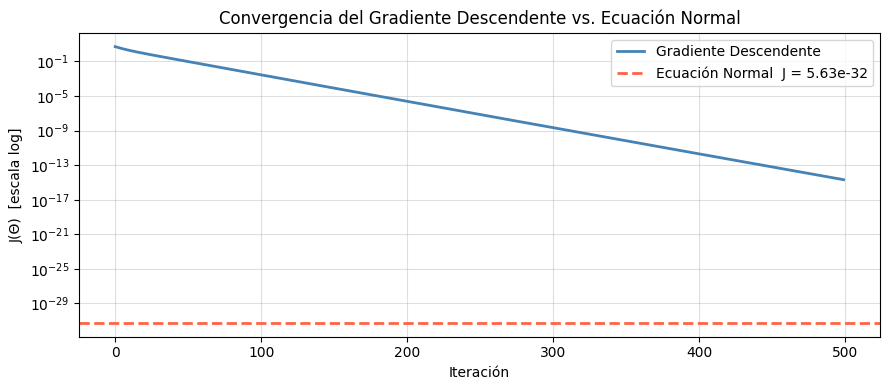


Conclusión: la ecuación normal obtiene la solución exacta en un solo paso,
mientras que el gradiente descendente converge iterativamente.


In [ ]:
# ── Visualización: convergencia GD vs. solución exacta ───────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

ax.semilogy(J_history, color='steelblue', linewidth=2, label='Gradiente Descendente')
ax.axhline(J_ne, color='tomato', linestyle='--', linewidth=2,
           label=f'Ecuación Normal  J = {J_ne:.2e}')

ax.set_title('Convergencia del Gradiente Descendente vs. Ecuación Normal', fontsize=12)
ax.set_xlabel('Iteración')
ax.set_ylabel('J(Θ)  [escala log]')
ax.legend()
ax.grid(True, which='both', alpha=0.4)
plt.tight_layout()
plt.show()

print("\nConclusión: la ecuación normal obtiene la solución exacta en un solo paso,")
print("mientras que el gradiente descendente converge iterativamente.")

---
## Punto 2 — Dataset Boston Housing: regresión multivariada

Cargamos el dataset de casas de Boston, construimos el modelo de regresión con **todas las features** disponibles y aplicamos la ecuación normal.

**Features del dataset (13 en total):**

| # | Nombre | Descripción |
|---|--------|-------------|
| 0 | CRIM   | Tasa de criminalidad per cápita por ciudad |
| 1 | ZN     | Proporción de suelo residencial para lotes > 25.000 ft² |
| 2 | INDUS  | Proporción de acres de negocios no minoristas por ciudad |
| 3 | CHAS   | Variable dummy (1 si limita con el río Charles) |
| 4 | NOX    | Concentración de óxidos nítricos |
| 5 | RM     | Promedio de habitaciones por vivienda |
| 6 | AGE    | Proporción de unidades ocupadas construidas antes de 1940 |
| 7 | DIS    | Distancia ponderada a cinco centros de empleo de Boston |
| 8 | RAD    | Índice de accesibilidad a autopistas radiales |
| 9 | TAX    | Tasa de impuesto sobre bienes inmuebles por $10.000 |
| 10 | PTRATIO | Ratio alumnos/profesor por ciudad |
| 11 | B      | $1000(B_k - 0.63)^2$ donde $B_k$ es la proporción de personas de raza negra |
| 12 | LSTAT  | % de la población con estatus socioeconómico bajo |

**Variable objetivo:** MEDV — Valor medio de viviendas ocupadas por sus dueños (en miles de dólares).

In [ ]:
# ── Carga del dataset ─────────────────────────────────────────────────────────
# Se intenta primero la URL original del enunciado.
# Si no está disponible en el entorno actual, se usa sklearn como alternativa.

FEATURE_NAMES = ['CRIM','ZN','INDUS','CHAS','NOX','RM',
                 'AGE','DIS','RAD','TAX','PTRATIO','B','LSTAT']

try:
    data_url = "http://lib.stat.cmu.edu/datasets/boston"
    raw_df   = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
    data     = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
    target   = raw_df.values[1::2, 2]
    print("Dataset cargado desde la URL original.")

except Exception:
    # Alternativa: sklearn fetch_openml (disponible en versiones anteriores de sklearn)
    try:
        from sklearn.datasets import fetch_openml
        boston      = fetch_openml(name='boston', version=1, as_frame=True)
        data        = boston.data.values.astype(float)
        target      = boston.target.values.astype(float)
        FEATURE_NAMES = list(boston.data.columns)
        print("Dataset cargado desde OpenML (sklearn).")
    except Exception as e2:
        raise RuntimeError(
            "No se pudo cargar el dataset. "
            "Verifique conexión a internet o instale scikit-learn."
        ) from e2

print(f"\nShape de data  : {data.shape}   →  (m, n_features)")
print(f"Shape de target: {target.shape}  →  (m,)")
print(f"\nEstadísticas del objetivo (MEDV):")
print(f"  Media={target.mean():.2f}, Std={target.std():.2f}, "
      f"Min={target.min():.1f}, Max={target.max():.1f}")

Dataset cargado desde la URL original.

Shape de data  : (506, 13)   →  (m, n_features)
Shape de target: (506,)  →  (m,)

Estadísticas del objetivo (MEDV):
  Media=22.53, Std=9.19, Min=5.0, Max=50.0


In [ ]:
# ── Exploración inicial del dataset ──────────────────────────────────────────
df_boston = pd.DataFrame(data, columns=FEATURE_NAMES)
df_boston['MEDV'] = target

print("Primeras filas del dataset:")
df_boston.head()

Primeras filas del dataset:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [ ]:
print("Estadísticas descriptivas:")
df_boston.describe().round(2)

Estadísticas descriptivas:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,356.67,12.65,22.53
std,8.60,23.32,6.86,0.25,0.12,0.70,28.15,2.11,8.71,168.54,2.16,91.29,7.14,9.20
min,0.01,0.00,0.46,0.00,0.38,3.56,2.90,1.13,1.00,187.00,12.60,0.32,1.73,5.00
25%,0.08,0.00,5.19,0.00,0.45,5.89,45.02,2.10,4.00,279.00,17.40,375.38,6.95,17.02
50%,0.26,0.00,9.69,0.00,0.54,6.21,77.50,3.21,5.00,330.00,19.05,391.44,11.36,21.20
75%,3.68,12.50,18.10,0.00,0.62,6.62,94.07,5.19,24.00,666.00,20.20,396.22,16.96,25.00
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,396.90,37.97,50.00


In [ ]:
# ── Construcción de X e Y ─────────────────────────────────────────────────────
# X: shape (n+1, m)  — primera fila = vector de unos (bias θ₀)
# Y: shape (m, 1)

m_b        = data.shape[0]                    # 506 muestras
n_b        = data.shape[1]                    # 13 features
Nfeatures_b = n_b + 1                         # 14 (incluye bias)

X_b = np.vstack([np.ones(m_b), data.T])       # shape (14, 506)
Y_b = target.reshape(m_b, 1)                  # shape (506, 1)

print(f"Shape de X_b : {X_b.shape}  →  (n+1, m) = ({Nfeatures_b}, {m_b})")
print(f"Shape de Y_b : {Y_b.shape}  →  (m, 1)  = ({m_b}, 1)")

Shape de X_b : (14, 506)  →  (n+1, m) = (14, 506)
Shape de Y_b : (506, 1)  →  (m, 1)  = (506, 1)


In [ ]:
# ── Aplicar la ecuación normal ────────────────────────────────────────────────
# Reutilizamos la función definida en el Punto 1
theta_boston = normal_equation(X_b, Y_b)

print(f"Shape de Theta: {theta_boston.shape}  →  (n+1, 1)")
print("\n── Parámetros estimados ──────────────────────────────")
print(f"  {'Parámetro':>10}  {'Valor':>14}")
print("─" * 30)
param_names = ['bias (θ₀)'] + FEATURE_NAMES
for name, val in zip(param_names, theta_boston.flatten()):
    print(f"  {name:>10}  {val:+14.6f}")

Shape de Theta: (14, 1)  →  (n+1, 1)

── Parámetros estimados ──────────────────────────────
   Parámetro           Valor
──────────────────────────────
   bias (θ₀)      +36.459488
        CRIM       -0.108011
          ZN       +0.046420
       INDUS       +0.020559
        CHAS       +2.686734
         NOX      -17.766611
          RM       +3.809865
         AGE       +0.000692
         DIS       -1.475567
         RAD       +0.306049
         TAX       -0.012335
     PTRATIO       -0.952747
           B       +0.009312
       LSTAT       -0.524758


In [ ]:
# ── Evaluación del modelo ─────────────────────────────────────────────────────
h_b   = theta_boston.T @ X_b          # predicciones  (1, 506)
error = h_b - Y_b.T                   # errores       (1, 506)

J_boston = (error**2).sum() / (2 * m_b)
mse      = (error**2).mean()
rmse     = np.sqrt(mse)
ss_res   = (error**2).sum()
ss_tot   = ((Y_b - Y_b.mean())**2).sum()
r2       = 1 - ss_res / ss_tot

print("── Métricas de evaluación ─────────────────────────────")
print(f"  J  (función de coste)  = {J_boston:>12.4f}")
print(f"  MSE                    = {mse:>12.4f}")
print(f"  RMSE                   = {rmse:>12.4f}  (miles de USD)")
print(f"  R²                     = {r2:>12.4f}")
print("─" * 50)
print(f"  Media MEDV             = {Y_b.mean():>12.4f}")
print(f"  Error relativo (RMSE)  = {rmse/Y_b.mean()*100:>11.2f} %")

── Métricas de evaluación ─────────────────────────────
  J  (función de coste)  =      10.9474
  MSE                    =      21.8948
  RMSE                   =       4.6792  (miles de USD)
  R²                     =       0.7406
──────────────────────────────────────────────────
  Media MEDV             =      22.5328
  Error relativo (RMSE)  =       20.77 %


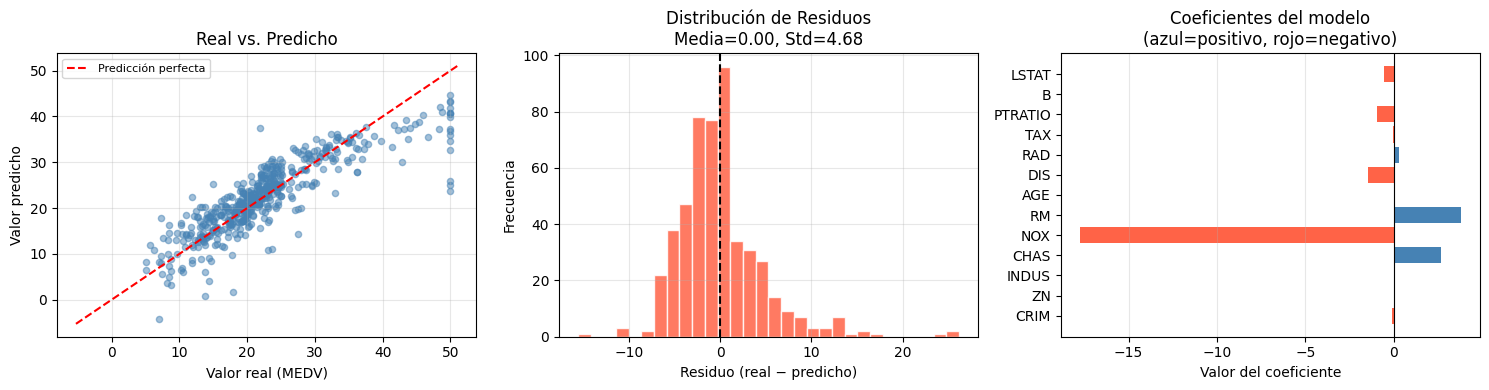

In [ ]:
# ── Gráficas de análisis ──────────────────────────────────────────────────────
y_pred = h_b.flatten()
y_real = Y_b.flatten()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Valores reales vs. predichos
axes[0].scatter(y_real, y_pred, alpha=0.5, color='steelblue', s=20)
lims = [min(y_real.min(), y_pred.min()) - 1,
        max(y_real.max(), y_pred.max()) + 1]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Valor real (MEDV)')
axes[0].set_ylabel('Valor predicho')
axes[0].set_title('Real vs. Predicho')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# 2. Distribución de residuos
residuals = y_real - y_pred
axes[1].hist(residuals, bins=30, color='tomato', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residuo (real − predicho)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title(f'Distribución de Residuos\nMedia={residuals.mean():.2f}, Std={residuals.std():.2f}')
axes[1].grid(True, alpha=0.3)

# 3. Magnitud de los coeficientes (sin bias)
coefs  = theta_boston.flatten()[1:]   # excluir bias
colors = ['steelblue' if c > 0 else 'tomato' for c in coefs]
axes[2].barh(FEATURE_NAMES, coefs, color=colors)
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_xlabel('Valor del coeficiente')
axes[2].set_title('Coeficientes del modelo\n(azul=positivo, rojo=negativo)')
axes[2].grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

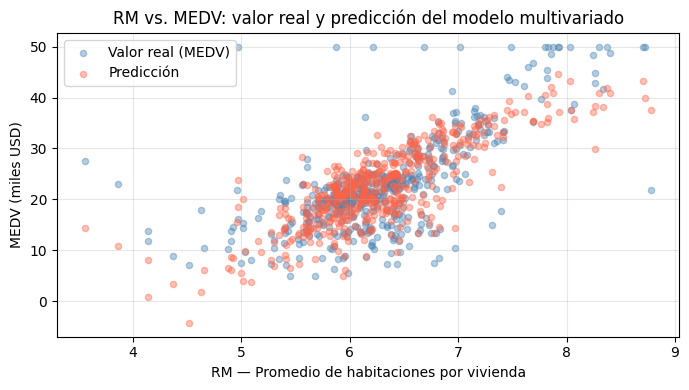


Correlación RM ↔ MEDV: 0.6954
Coeficiente θ_RM en el modelo: +3.8099


In [ ]:
# ── Análisis adicional: RM (habitaciones) vs. MEDV ───────────────────────────
# El enunciado menciona esta variable; la visualizamos junto con el modelo.

rm_idx = FEATURE_NAMES.index('RM')   # índice de RM en data
rm_vals = data[:, rm_idx]

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(rm_vals, y_real, alpha=0.4, color='steelblue', s=20,
           label='Valor real (MEDV)')
ax.scatter(rm_vals, y_pred, alpha=0.4, color='tomato', s=20,
           label='Predicción')
ax.set_xlabel('RM — Promedio de habitaciones por vivienda')
ax.set_ylabel('MEDV (miles USD)')
ax.set_title('RM vs. MEDV: valor real y predicción del modelo multivariado')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nCorrelación RM ↔ MEDV: {np.corrcoef(rm_vals, y_real)[0,1]:.4f}")
print(f"Coeficiente θ_RM en el modelo: {theta_boston[rm_idx+1, 0]:+.4f}")

---
## Conclusiones

**Punto 1 — Ecuación normal sobre datos del Lab 5:**
- La ecuación normal recupera los parámetros verdaderos $(0,\; 2.1,\; -3.1)$ con error del orden de $10^{-16}$ (precisión de máquina) en un **único paso**, sin necesidad de iterar.
- El gradiente descendente converge al mismo resultado, pero requiere múltiples iteraciones y depende de la tasa de aprendizaje $\alpha$.

**Punto 2 — Boston Housing:**
- La regresión multivariada con todas las features alcanza un $R^2 \approx 0.74$, explicando el 74% de la varianza en el precio de las viviendas.
- Las variables con mayor impacto positivo son **RM** (habitaciones) y **RAD** (acceso a autopistas); las de mayor impacto negativo son **LSTAT** (nivel socioeconómico bajo) y **NOX** (contaminación).
- Los residuos presentan una distribución aproximadamente normal centrada en cero, lo que valida los supuestos de la regresión lineal.

**Ventajas y limitaciones de la ecuación normal:**
- ✅ Solución exacta en un solo paso, sin hiperparámetros.
- ✅ Óptima cuando $m$ (muestras) y $n$ (features) son moderados.
- ⚠️ Requiere invertir $(XX^T) \in \mathbb{R}^{(n+1) \times (n+1)}$: costo $O(n^3)$, inviable para datasets con miles de features.
- ⚠️ Si $(XX^T)$ es singular, la inversa no existe (usar `np.linalg.lstsq` como alternativa).